# 02 — Resume Category Classifier (Model A, Supervised)

TF-IDF + Logistic Regression multi-class classifier that predicts a candidate's job domain
from raw resume text. This notebook mirrors `src/models/classifier.py` / `scripts/train_all.py`
but with extra inspection (confusion matrix, per-class report, a few misclassified examples).

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_data, preprocess
from src.models import classifier
from src import config

## 1. Load & clean resumes

In [2]:
resumes_raw = load_data.load_resumes()
resumes_clean = preprocess.clean_resumes(resumes_raw)
resumes_clean.head(3)

,category,resume_text,clean_text,years_experience
0,HR,TECHNICAL SKILLS â¢ Typewriting â¢ TORA â¢ ...,technical skills typewriting tora spsseducatio...,0.0
1,HR,"I.T. Skills â¢ Windows XP, Ms Office (Word, E...",i.t. skills windows xp ms office word excel lo...,0.0
2,HR,Education Details \r\n BA mumbai University\...,education details ba mumbai university hr skil...,0.0


## 2. Train / compare model types
The brief suggests Logistic Regression, Random Forest, or SVM — compare all three.

In [3]:
results = {}
for model_type in ['logreg', 'random_forest', 'svm']:
    model, vectorizer, label_encoder, metrics = classifier.train_classifier(resumes_clean, model_type=model_type)
    results[model_type] = metrics
    print(f"{model_type:14s}  acc={metrics['accuracy']:.3f}  f1_macro={metrics['f1_macro']:.3f}")

logreg          acc=0.703  f1_macro=0.701
random_forest   acc=0.784  f1_macro=0.772
svm             acc=0.739  f1_macro=0.739


## 3. Pick the best model and inspect it in detail

In [4]:
best_type = max(results, key=lambda k: results[k]['f1_macro'])
print('Best model:', best_type)
model, vectorizer, label_encoder, metrics = classifier.train_classifier(resumes_clean, model_type=best_type)

Best model: random_forest


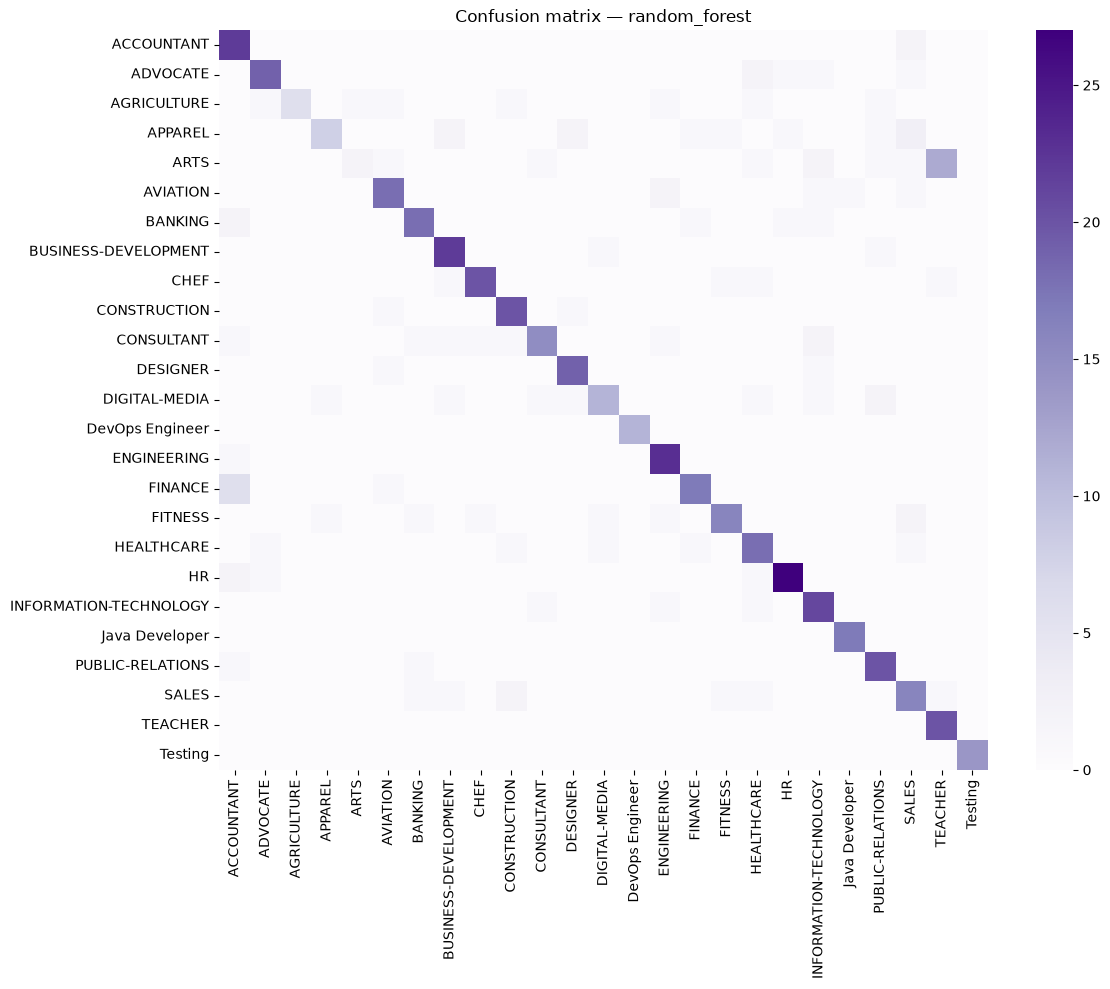

In [5]:
import seaborn as sns  # optional, falls back gracefully if unavailable
cm = np.array(metrics['confusion_matrix'])
labels = metrics['labels']

plt.figure(figsize=(12,10))
try:
    sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap='Purples')
except Exception:
    plt.imshow(cm, cmap='Purples')
plt.xticks(rotation=90)
plt.title(f'Confusion matrix — {best_type}')
plt.tight_layout()
plt.show()

In [6]:
pd.DataFrame(metrics['classification_report']).T.round(3)

,precision,recall,f1-score,support
ACCOUNTANT,0.629,0.917,0.746,24.000
ADVOCATE,0.864,0.792,0.826,24.000
AGRICULTURE,1.000,0.462,0.632,13.000
APPAREL,0.800,0.421,0.552,19.000
ARTS,0.667,0.095,0.167,21.000
AVIATION,0.783,0.783,0.783,23.000
BANKING,0.818,0.783,0.800,23.000
BUSINESS-DEVELOPMENT,0.786,0.917,0.846,24.000
CHEF,0.909,0.833,0.870,24.000
CONSTRUCTION,0.800,0.909,0.851,22.000


## 4. Save the chosen model
(`scripts/train_all.py` always trains & saves logreg by default for reproducibility — swap `model_type` there if this notebook shows a different winner.)

In [6]:
classifier.save_classifier(model, vectorizer, label_encoder)
print('Saved to', config.CLASSIFIER_MODEL)

Saved to C:\Users\Srilatha Reddy\Downloads\smarthire\smarthire\models\resume_classifier.pkl


## 5. Try it on a custom snippet

In [7]:
sample_text = '''Senior human resources manager with 8 years of experience in recruitment,
employee relations, payroll, onboarding and performance management.'''
clean = preprocess.clean_text(sample_text)
preds = classifier.predict_category(clean, model, vectorizer, label_encoder, top_k=3)
preds

[('HR', 0.46), ('BUSINESS-DEVELOPMENT', 0.23), ('PUBLIC-RELATIONS', 0.07)]